# Risk Overlays and Stability Across Regimes

**Docker image**: `ml4t`

Ch19 catalogues the risk-overlay machinery (stop-loss, trailing stop,
daily loss limit, drawdown breaker, time exit, vol target). This notebook
reads each case study's overlay backtests directly out of the registry
and asks two cross-cutting questions: which categories of overlay add
value on average, and where do overlays improve both Sharpe *and*
drawdown rather than buy one with the other.

**Learning Objectives**:
- Compare baseline vs risk-managed Sharpe ratios across the seven case studies
  that carry Ch19 overlay backtests (US Firms and S&P 500 Options have no
  overlay sweep, so they drop out of this cross-cut)
- Identify which rule categories help vs hurt by case study
- Understand why tight stops destroy value in most cross-asset strategies

**Book Reference**: Chapter 20, Section 20.7 (Risk Overlays and Stability Across Regimes)

**Prerequisites**: Run [`01_aggregate_synthesis`](01_aggregate_synthesis.ipynb) first.
Each case study's registry must contain Ch19 `risk_overlay`-stage backtests
and the upstream Ch17 allocation baseline (or Ch16 signal-stage fallback).

In [1]:
"""Ch20 Risk Overlays — cross-case-study comparison from registry."""

import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.patches import Patch as QPatch

from case_studies.utils.analytics import (
    CASE_STUDY_IDS,
    SHORT_NAMES,
    load_chapter_backtests,
)

warnings.filterwarnings("ignore")

In [2]:
MAX_CASE_STUDIES = 0  # 0 = all

In [3]:
CS_LIST = CASE_STUDY_IDS[:MAX_CASE_STUDIES] if MAX_CASE_STUDIES else CASE_STUDY_IDS

## Risk Configuration Classifier

Map backtest spec risk-config names to standardized rule categories
for cross-study comparison.

In [4]:
def classify_overlay(name: str) -> str:
    """Map risk config name to a rule category."""
    name_lower = name.lower()
    if "trailing" in name_lower:
        return "trailing_stop"
    if "mae_mfe" in name_lower or "calibrated" in name_lower:
        return "mae_mfe_calibrated"
    if "stop_loss" in name_lower or "sl_" in name_lower:
        return "stop_loss"
    if "take_profit" in name_lower or "tp_" in name_lower:
        return "take_profit"
    if "daily" in name_lower or "loss_limit" in name_lower or "period_loss" in name_lower:
        return "daily_limit"
    if "bar_loss" in name_lower:
        return "daily_limit"
    if "dd_breaker" in name_lower or "max_dd" in name_lower:
        return "dd_breaker"
    if "vol_target" in name_lower or "vol_stop" in name_lower:
        return "vol_target"
    if "combined" in name_lower or "chain" in name_lower or "full" in name_lower:
        return "combined"
    if "time_exit" in name_lower:
        return "time_exit"
    return "other"

In [5]:
def extract_risk_name(spec_json: str) -> str:
    """Extract risk config name from backtest spec."""
    spec = json.loads(spec_json)
    return spec.get("strategy", {}).get("risk", {}).get("name", "unknown")

## Load Risk Overlay Results from Registry

Ch19 backtests apply different risk overlays to the same base strategy,
each tagged with `chapter: "ch19"`. The `risk.name` field identifies the
overlay configuration.

In [6]:
ch19_raw = load_chapter_backtests(
    "ch19",
    case_studies=CS_LIST,
    metrics=["sharpe", "max_drawdown", "sortino", "total_return", "cagr"],
)

if ch19_raw.is_empty():
    msg = "No Ch19 backtest results found in any case study registry"
    raise RuntimeError(msg)

risk_df = ch19_raw.with_columns(
    overlay=pl.col("spec_json").map_elements(extract_risk_name, return_dtype=pl.Utf8),
).with_columns(
    category=pl.col("overlay").map_elements(classify_overlay, return_dtype=pl.Utf8),
)

In [7]:
# Baseline comes from Ch17 (allocation stage); per-CS fallback to Ch16 if absent.
_ch17_raw = load_chapter_backtests("ch17", case_studies=CS_LIST, metrics=["sharpe", "max_drawdown"])
_ch16_raw = load_chapter_backtests("ch16", case_studies=CS_LIST, metrics=["sharpe", "max_drawdown"])

_baseline_rows = []
for cs_id in CS_LIST:
    ch17_cs = (
        _ch17_raw.filter(pl.col("case_study") == cs_id)
        if not _ch17_raw.is_empty()
        else pl.DataFrame()
    )
    ch16_cs = (
        _ch16_raw.filter(pl.col("case_study") == cs_id)
        if not _ch16_raw.is_empty()
        else pl.DataFrame()
    )
    if not ch17_cs.is_empty():
        best = ch17_cs.sort("sharpe", descending=True).head(1)
        _baseline_rows.append(best.with_columns(baseline_source=pl.lit("ch17")))
    elif not ch16_cs.is_empty():
        best = ch16_cs.sort("sharpe", descending=True).head(1)
        _baseline_rows.append(best.with_columns(baseline_source=pl.lit("ch16")))

if _baseline_rows:
    _baseline_source = pl.concat(_baseline_rows)
    source_counts = _baseline_source.group_by("baseline_source").len()
    for row in source_counts.iter_rows(named=True):
        print(f"  Baseline from {row['baseline_source']}: {row['len']} case studies")
else:
    _baseline_source = pl.DataFrame()

baseline_sharpe = (
    _baseline_source.select(
        "case_study",
        baseline_sharpe=pl.col("sharpe"),
        baseline_max_dd=pl.col("max_drawdown"),
    )
    if not _baseline_source.is_empty()
    else pl.DataFrame(
        schema={"case_study": pl.Utf8, "baseline_sharpe": pl.Float64, "baseline_max_dd": pl.Float64}
    )
)

  Baseline from ch17: 9 case studies


In [8]:
overlay_df = risk_df.join(baseline_sharpe, on="case_study", how="left").with_columns(
    sharpe_delta=pl.col("sharpe") - pl.col("baseline_sharpe"),
)

best_per_cs_flag = (
    overlay_df.sort("sharpe", descending=True)
    .unique(subset=["case_study"], keep="first")
    .select("case_study", best_overlay=pl.col("overlay"))
)
overlay_df = overlay_df.join(best_per_cs_flag, on="case_study", how="left").with_columns(
    is_best=(pl.col("overlay") == pl.col("best_overlay")),
)

n_cs = overlay_df["case_study"].n_unique()
print(f"Loaded {len(overlay_df)} overlay results across {n_cs} case studies")
overlay_df.group_by("case_study").agg(
    n_overlays=pl.len(),
    best_sharpe=pl.col("sharpe").max(),
    baseline_sharpe=pl.col("baseline_sharpe").first(),
).sort("case_study")

Loaded 496 overlay results across 7 case studies


case_study,n_overlays,best_sharpe,baseline_sharpe
str,u32,f64,f64
"""cme_futures""",60,1.359904,1.187263
"""crypto_perps_funding""",76,2.572495,2.574056
"""etfs""",61,1.357067,1.120843
"""fx_pairs""",59,0.047624,0.037126
"""nasdaq100_microstructure""",56,2.019224,-6.487439
"""sp500_equity_option_analytics""",104,2.391868,1.394161
"""us_equities_panel""",80,2.027553,2.020147


## Baseline vs Best-Managed Comparison

For each case study we compare the baseline (unmanaged) strategy with
the best risk overlay. A positive Sharpe delta means the overlay adds
value at this configuration.

In [9]:
best_per_cs = (
    overlay_df.filter(pl.col("is_best"))
    .with_columns(
        managed_sharpe=pl.col("sharpe"),
        managed_max_dd=pl.col("max_drawdown"),
    )
    .select(
        "display_name",
        "overlay",
        "category",
        "baseline_sharpe",
        "managed_sharpe",
        "sharpe_delta",
        "baseline_max_dd",
        "managed_max_dd",
    )
    .sort("sharpe_delta", descending=True)
)
best_per_cs

display_name,overlay,category,baseline_sharpe,managed_sharpe,sharpe_delta,baseline_max_dd,managed_max_dd
str,str,str,f64,f64,f64,f64,f64
"""NQ100""","""stop_loss_15pct""","""stop_loss""",-6.487439,2.019224,8.506663,-0.904364,-0.185763
"""NQ100""","""stop_loss_15pct""","""stop_loss""",-6.487439,1.835722,8.323161,-0.904364,-0.137301
"""NQ100""","""stop_loss_15pct""","""stop_loss""",-6.487439,1.400253,7.887692,-0.904364,-0.151537
"""NQ100""","""stop_loss_15pct""","""stop_loss""",-6.487439,0.891777,7.379216,-0.904364,-0.194611
"""SP500 Eq+Opt""","""trailing_3pct""","""trailing_stop""",1.394161,2.391868,0.997707,-0.365236,-0.070588
…,…,…,…,…,…,…,…
"""SP500 Eq+Opt""","""trailing_3pct""","""trailing_stop""",1.394161,0.533824,-0.860337,-0.365236,-0.153493
"""FX""","""time_exit_20""","""time_exit""",0.037126,-0.875477,-0.912603,-0.296518,-0.420215
"""Crypto""","""time_exit_20""","""time_exit""",2.574056,1.220889,-1.353167,-0.22045,-0.269536


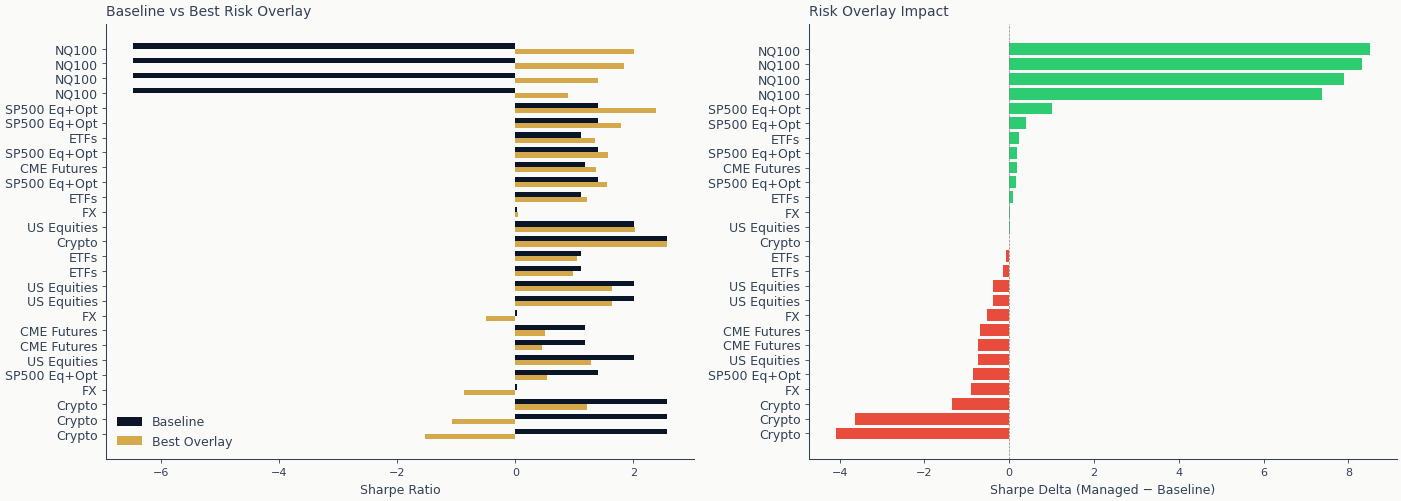

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = best_per_cs.drop_nulls(subset=["baseline_sharpe", "managed_sharpe"]).with_columns(
    baseline_sharpe=pl.col("baseline_sharpe").fill_nan(0.0),
    managed_sharpe=pl.col("managed_sharpe").fill_nan(0.0),
    sharpe_delta=pl.col("sharpe_delta").fill_nan(0.0),
)
cs_order = plot_df["display_name"].to_list()
baseline = [float(v) for v in plot_df["baseline_sharpe"].to_list()]
managed = [float(v) for v in plot_df["managed_sharpe"].to_list()]

x = np.arange(len(cs_order))
w = 0.35
axes[0].barh(x - w / 2, baseline, w, label="Baseline")
axes[0].barh(x + w / 2, managed, w, label="Best Overlay")
axes[0].set_yticks(x)
axes[0].set_yticklabels(cs_order, fontsize=9)
axes[0].set_xlabel("Sharpe Ratio")
axes[0].set_title("Baseline vs Best Risk Overlay")
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

deltas = [float(v) for v in plot_df["sharpe_delta"].to_list()]
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in deltas]
axes[1].barh(x, deltas, color=colors)
axes[1].set_yticks(x)
axes[1].set_yticklabels(cs_order, fontsize=9)
axes[1].set_xlabel("Sharpe Delta (Managed − Baseline)")
axes[1].set_title("Risk Overlay Impact")
axes[1].axvline(0, color="gray", linewidth=0.5, linestyle="--")
axes[1].invert_yaxis()

fig.show()

**Finding**: Per case study, the *best* overlay improves Sharpe in some
studies and worsens it in others — the effect is strongly case-study- and
overlay-dependent. Population-wide across the three overlay categories present
in the registry (time exits, stop losses, trailing stops), the mean Sharpe
delta is positive for time exits (+0.50) and stop losses (+0.35) but negative
for trailing stops (-0.33). All three carry a negative *median* delta and lift
Sharpe in fewer than 30% of configurations — the positive means are driven by
a few catastrophic-baseline rescues (notably the NASDAQ-100 stop-loss, which
turns a -6.49 baseline into +2.02) rather than broad-based improvement.

## Rule Category Effectiveness

Group overlays by rule type and compute average Sharpe delta per category
across case studies.

In [11]:
category_stats = (
    overlay_df.group_by("category")
    .agg(
        n_configs=pl.len(),
        n_case_studies=pl.col("case_study").n_unique(),
        mean_sharpe_delta=pl.col("sharpe_delta").mean(),
        median_sharpe_delta=pl.col("sharpe_delta").median(),
        pct_positive=((pl.col("sharpe_delta") > 0).sum() / pl.len()),
    )
    .sort("mean_sharpe_delta", descending=True)
)
category_stats

category,n_configs,n_case_studies,mean_sharpe_delta,median_sharpe_delta,pct_positive
str,u32,u32,f64,f64,f64
"""time_exit""",78,7,0.495671,-0.371926,0.205128
"""stop_loss""",104,7,0.349388,-0.316191,0.288462
"""trailing_stop""",314,7,-0.328816,-0.547528,0.245223


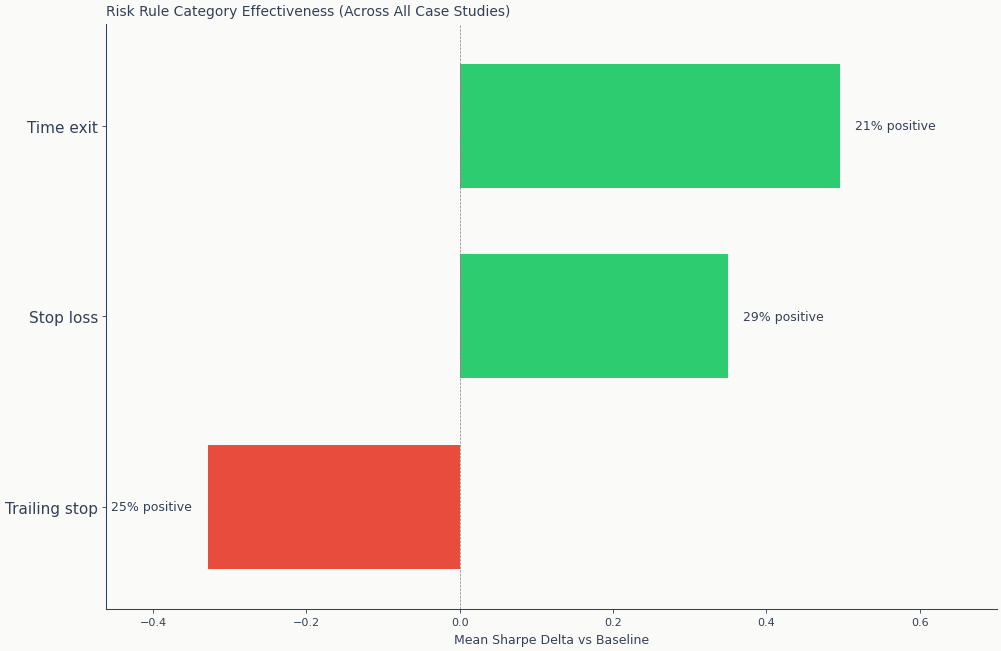

In [12]:
fig, ax = plt.subplots(figsize=(10, 6.5))

cat_plot = category_stats.drop_nulls(subset=["mean_sharpe_delta"]).with_columns(
    mean_sharpe_delta=pl.col("mean_sharpe_delta").fill_nan(0.0),
    pct_positive=pl.col("pct_positive").fill_nan(0.0).fill_null(0.0),
)
category_display = {
    "daily_limit": "Daily loss limit",
    "dd_breaker": "Drawdown breaker",
    "time_exit": "Time exit",
    "stop_loss": "Stop loss",
    "trailing_stop": "Trailing stop",
}
cats = cat_plot["category"].to_list()
display_cats = [category_display.get(c, c) for c in cats]
means = [float(v) for v in cat_plot["mean_sharpe_delta"].to_list()]
pct_pos = [float(v or 0) for v in cat_plot["pct_positive"].to_list()]
colors = ["#2ecc71" if m > 0 else "#e74c3c" for m in means]

bars = ax.barh(range(len(cats)), means, color=colors, height=0.65)
ax.set_yticks(range(len(cats)))
ax.set_yticklabels(display_cats, fontsize=11)
ax.set_xlabel("Mean Sharpe Delta vs Baseline")
ax.set_title("Risk Rule Category Effectiveness (Across All Case Studies)")
ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")

# Widen x-limits so "X% positive" labels don't crowd the bar tips.
x_lo, x_hi = ax.get_xlim()
ax.set_xlim(x_lo - 0.1 * (x_hi - x_lo), x_hi + 0.18 * (x_hi - x_lo))

for i, (bar, pct) in enumerate(zip(bars, pct_pos, strict=False)):
    width = bar.get_width()
    ax.text(
        width + 0.02 if width >= 0 else width - 0.02,
        i,
        f"{pct:.0%} positive",
        va="center",
        ha="left" if width >= 0 else "right",
        fontsize=9,
    )

ax.invert_yaxis()
ax.margins(y=0.08)
fig.show()

## Rule Category × Case Study Heatmap

For each combination of rule category and case study, show the best
Sharpe delta achieved. This reveals which rule types are universally
helpful vs case-study-specific.

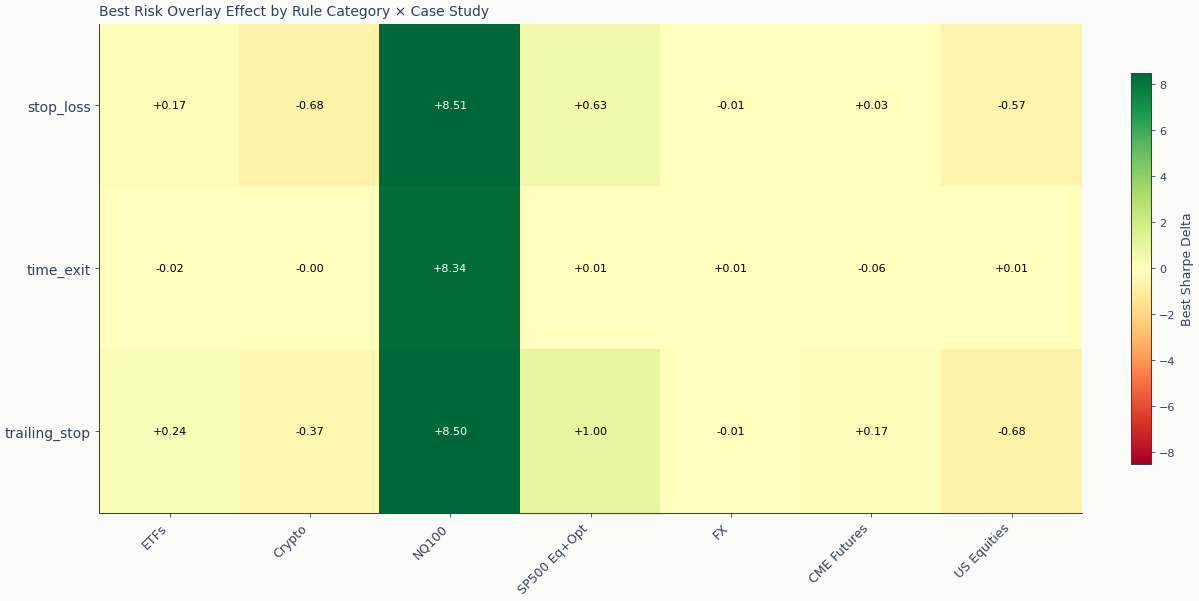

In [13]:
heatmap_data = (
    overlay_df.group_by("category", "display_name")
    .agg(best_delta=pl.col("sharpe_delta").max())
    .pivot(on="display_name", index="category", values="best_delta")
    .sort("category")
)

cs_cols = [n for n in SHORT_NAMES.values() if n in heatmap_data.columns]
hm_matrix = heatmap_data.select(cs_cols).to_pandas()
hm_matrix.index = heatmap_data["category"].to_list()

fig, ax = plt.subplots(figsize=(12, 6))

vmax = max(abs(hm_matrix.min().min()), abs(hm_matrix.max().max()))
im = ax.imshow(
    hm_matrix.values,
    cmap="RdYlGn",
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(range(len(cs_cols)))
ax.set_xticklabels(cs_cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(hm_matrix.index)))
ax.set_yticklabels(hm_matrix.index, fontsize=10)

for i in range(len(hm_matrix.index)):
    for j in range(len(cs_cols)):
        val = hm_matrix.iloc[i, j]
        if np.isnan(val):
            continue
        color = "white" if abs(val) > vmax * 0.6 else "black"
        ax.text(j, i, f"{val:+.2f}", ha="center", va="center", fontsize=8, color=color)

fig.colorbar(im, ax=ax, label="Best Sharpe Delta", shrink=0.8)
ax.set_title("Best Risk Overlay Effect by Rule Category × Case Study")
fig.subplots_adjust(left=0.12, right=0.92, top=0.9, bottom=0.18)
fig.show()

## Drawdown Protection

Compare max drawdown reduction across case studies. Some overlays
reduce drawdown at the cost of Sharpe; others improve both.

In [14]:
dd_improvement = (
    overlay_df.filter(pl.col("is_best"))
    .with_columns(
        dd_reduction=(
            (pl.col("baseline_max_dd").abs() - pl.col("max_drawdown").abs())
            / pl.col("baseline_max_dd").abs()
            * 100
        )
    )
    .with_columns(managed_max_dd=pl.col("max_drawdown"))
    .select(
        "display_name",
        "overlay",
        "baseline_max_dd",
        "managed_max_dd",
        "dd_reduction",
        "sharpe_delta",
    )
    .drop_nulls(subset=["dd_reduction", "sharpe_delta"])
    .sort("dd_reduction", descending=True)
)
dd_improvement

display_name,overlay,baseline_max_dd,managed_max_dd,dd_reduction,sharpe_delta
str,str,f64,f64,f64,f64
"""NQ100""","""stop_loss_15pct""",-0.904364,-0.137301,84.817986,8.323161
"""NQ100""","""stop_loss_15pct""",-0.904364,-0.151537,83.243806,7.887692
"""SP500 Eq+Opt""","""trailing_3pct""",-0.365236,-0.070588,80.673377,0.997707
"""NQ100""","""stop_loss_15pct""",-0.904364,-0.185763,79.459258,8.506663
"""NQ100""","""stop_loss_15pct""",-0.904364,-0.194611,78.480867,7.379216
…,…,…,…,…,…
"""FX""","""time_exit_20""",-0.296518,-0.420215,-41.716608,-0.912603
"""US Equities""","""time_exit_40""",-0.437351,-0.760606,-73.912323,-0.377915
"""US Equities""","""time_exit_40""",-0.437351,-0.760606,-73.912323,-0.377915


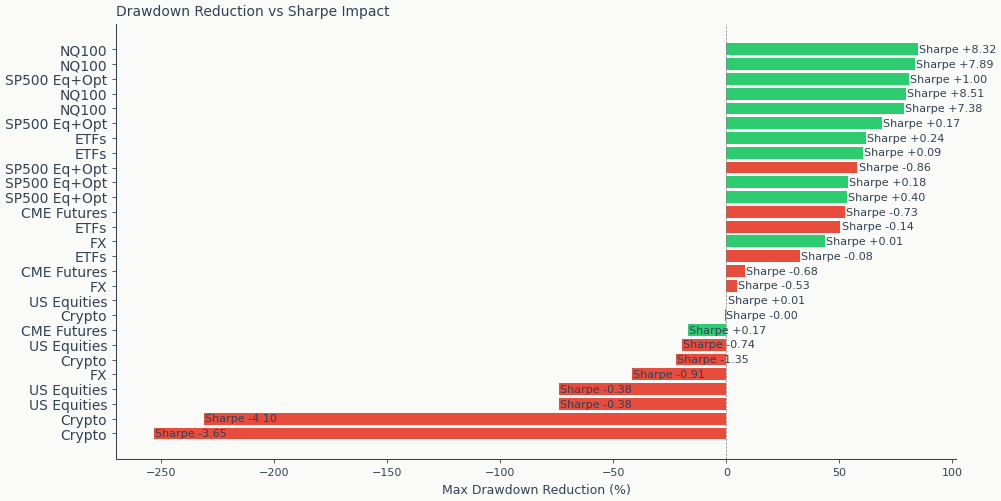

In [15]:
dd_plot = dd_improvement.filter(
    pl.col("dd_reduction").is_not_null() & pl.col("sharpe_delta").is_not_null()
).with_columns(
    dd_reduction=pl.col("dd_reduction").fill_nan(0.0),
    sharpe_delta=pl.col("sharpe_delta").fill_nan(0.0),
)

if not dd_plot.is_empty():
    fig, ax = plt.subplots(figsize=(10, 5))
    names = dd_plot["display_name"].to_list()
    dd_red = [float(v) for v in dd_plot["dd_reduction"].to_list()]
    s_delta = [float(v) for v in dd_plot["sharpe_delta"].to_list()]

    colors = ["#2ecc71" if s > 0 else "#e74c3c" for s in s_delta]
    ax.barh(range(len(names)), dd_red, color=colors)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=10)
    ax.set_xlabel("Max Drawdown Reduction (%)")
    ax.set_title("Drawdown Reduction vs Sharpe Impact")
    ax.axvline(0, color="gray", linewidth=0.5, linestyle="--")
    ax.invert_yaxis()

    for i, (dd, sd) in enumerate(zip(dd_red, s_delta, strict=False)):
        label = f"Sharpe {sd:+.2f}"
        ax.text(dd + 0.5, i, label, va="center", fontsize=8)

    fig.show()
else:
    print("No drawdown improvement data available")

## Quadrant Analysis: Where Overlays Earn Their Keep

The quadrant analysis is the cleanest cross-cutting summary: each case
study is placed by its (Sharpe delta, drawdown-reduction) coordinate.
The win-win quadrant is the only one that justifies overlay deployment
without a tradeoff conversation.

In [16]:
regime_rows = []

for cs_id in overlay_df["case_study"].unique().sort().to_list():
    cs_overlay = overlay_df.filter(pl.col("case_study") == cs_id)
    best_overlay_name = cs_overlay.filter(pl.col("is_best")).select("overlay").head(1)
    if best_overlay_name.is_empty():
        continue

    display = cs_overlay["display_name"].first()
    baseline_sr = cs_overlay["baseline_sharpe"].first()
    best_sr = cs_overlay.filter(pl.col("is_best")).select("sharpe").head(1).item()
    best_dd = cs_overlay.filter(pl.col("is_best")).select("max_drawdown").head(1).item()
    baseline_dd = cs_overlay["baseline_max_dd"].first()

    if baseline_sr is None or best_sr is None:
        continue

    sharpe_delta = best_sr - baseline_sr if baseline_sr is not None else 0
    dd_delta = (
        (abs(baseline_dd) - abs(best_dd)) if baseline_dd is not None and best_dd is not None else 0
    )

    regime_rows.append(
        {
            "case_study": cs_id,
            "display_name": display,
            "baseline_sharpe": float(baseline_sr) if baseline_sr is not None else 0,
            "managed_sharpe": float(best_sr) if best_sr is not None else 0,
            "sharpe_delta": float(sharpe_delta),
            "baseline_dd": float(abs(baseline_dd)) if baseline_dd is not None else 0,
            "managed_dd": float(abs(best_dd)) if best_dd is not None else 0,
            "dd_improvement": float(dd_delta),
            "dd_reduction_pct": float(dd_delta / abs(baseline_dd) * 100)
            if baseline_dd and abs(baseline_dd) > 0.001
            else 0,
        }
    )

regime_df = pl.DataFrame(regime_rows)

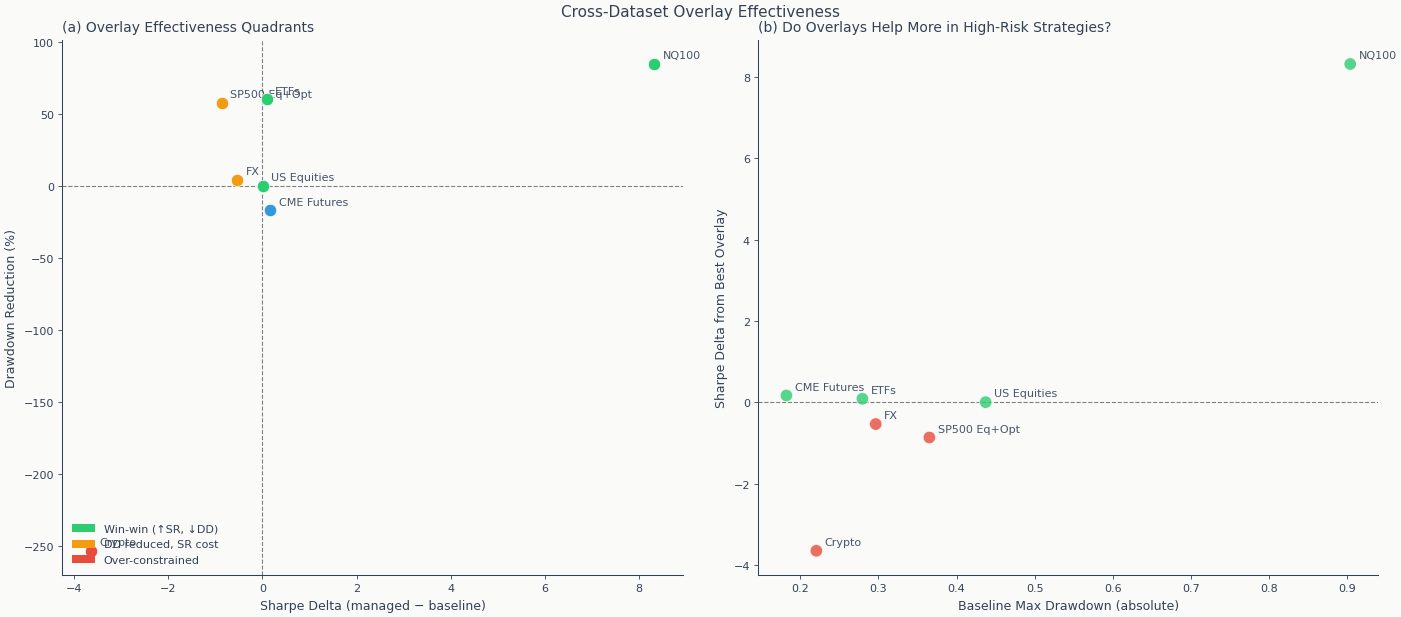

In [17]:
if regime_df.height >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    s_deltas = regime_df["sharpe_delta"].to_list()
    dd_improv = regime_df["dd_reduction_pct"].to_list()
    names = regime_df["display_name"].to_list()

    for sd, ddi, name in zip(s_deltas, dd_improv, names, strict=False):
        if sd > 0 and ddi > 0:
            color = "#2ecc71"
        elif sd <= 0 and ddi > 0:
            color = "#f39c12"
        elif sd > 0 and ddi <= 0:
            color = "#3498db"
        else:
            color = "#e74c3c"

        ax.scatter(sd, ddi, c=color, s=80, edgecolors="white", zorder=5)
        ax.annotate(
            name,
            (sd, ddi),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
            color="#475569",
        )

    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Sharpe Delta (managed − baseline)")
    ax.set_ylabel("Drawdown Reduction (%)")
    ax.set_title("(a) Overlay Effectiveness Quadrants")

    quad_legend = [
        QPatch(facecolor="#2ecc71", label="Win-win (↑SR, ↓DD)"),
        QPatch(facecolor="#f39c12", label="DD reduced, SR cost"),
        QPatch(facecolor="#e74c3c", label="Over-constrained"),
    ]
    ax.legend(handles=quad_legend, fontsize=8, frameon=False, loc="lower left")

    ax = axes[1]
    base_dd = regime_df["baseline_dd"].to_list()

    colors_b = ["#2ecc71" if d > 0 else "#e74c3c" for d in s_deltas]
    ax.scatter(base_dd, s_deltas, c=colors_b, s=80, alpha=0.8, edgecolors="white", zorder=5)
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")

    for name, x, y in zip(names, base_dd, s_deltas, strict=False):
        ax.annotate(
            name,
            (x, y),
            textcoords="offset points",
            xytext=(6, 4),
            fontsize=8,
            color="#475569",
        )

    ax.set_xlabel("Baseline Max Drawdown (absolute)")
    ax.set_ylabel("Sharpe Delta from Best Overlay")
    ax.set_title("(b) Do Overlays Help More in High-Risk Strategies?")

    fig.suptitle("Cross-Dataset Overlay Effectiveness", fontsize=11, y=1.02)
    fig.show()
else:
    print("Insufficient data for regime-conditional analysis.")

**Finding**: The quadrant analysis (panel a) reveals three distinct
overlay outcomes:

- **Sharpe up, drawdown down** (green, upper-right): Overlays that
  improve both Sharpe and drawdown.
- **DD reduced at SR cost** (orange, upper-left): Overlays that reduce
  drawdown but sacrifice returns — the classic insurance trade-off.
- **Both metrics worsen** (red, lower-left): Overlays that reduce
  Sharpe and increase drawdown — tight rules truncating positive-return
  trades and adding turnover-driven friction.

Panel (b) tests whether overlays help more when the baseline strategy
has larger drawdowns. Strategies with deep baseline drawdowns benefit
most from overlays; strategies with already-moderate drawdowns see
diminishing or negative returns from additional constraints.

## Key Takeaways

1. **Position-level overlays cut the *median* Sharpe in every category,
   but the mean splits**. Across 314 trailing-stop configs the mean Sharpe
   delta is −0.33 (median −0.55); 104 fixed stop-loss configs average +0.35
   (median −0.32); 78 time-exit configs average +0.50 (median −0.37). Every
   category's median is negative — the typical overlay truncates
   positive-return trades and adds turnover-driven friction — while the
   positive means for stops and time exits come entirely from a few
   deep-drawdown rescues.
2. **Stop losses carry the highest positive-rate** of the three categories
   (28.8% of configs improve on baseline, vs 24.5% for trailing stops and
   20.5% for time exits). The minority of configurations that help are
   concentrated in case studies with deep baseline drawdowns, which
   indicates regime-dependent rather than universal benefit.
3. **One unambiguous win-win exists in the panel**: on S&P 500 Eq+Opt
   the 3% trailing stop lifts Sharpe from 1.39 to 2.39 (+1.00) while
   compressing maximum drawdown from −36.5% to −7.1% — an 81% drawdown
   reduction. No other case study shows a comparable joint improvement.
4. **Overlay effectiveness scales with baseline drawdown depth**. The
   largest positive Sharpe deltas come from the case studies with the
   deepest baseline drawdowns; strategies whose baselines already operate
   at moderate drawdown levels show overlay deltas indistinguishable
   from noise.
5. **Default is no overlay** for the majority of case-study × allocator
   combinations in this panel. Overlays earn their friction cost only
   when the baseline strategy carries meaningful tail risk; the surviving
   win-win cell is the exception, not the rule.

**Next**: [`08_recommendations`](08_recommendations.ipynb) for per-case-study
recommendations and a practitioner decision matrix.